<a href="https://colab.research.google.com/github/ja2faded/A04-clustering/blob/main/A4jacksongayeskinotebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Assignment: $k$ Means Clustering


**Q1.** This is a question about clustering. We want to investigate how adjusting the "noisiness" of the data impacts the quality of the algorithm and the difficulty of picking $k$.

1. Run the code below, which creates four datasets: `df0_125`, `df0_25`, `df0_5`, `df1_0`, and `df2_0`. Each data set is created by increasing the amount of `noise` (standard deviation) around the cluster centers, from `0.125` to `0.25` to `0.5` to `1.0` to `2.0`.

```
import numpy as np
import pandas as pd

def createData(noise,N=50):
    np.random.seed(100) # Set the seed for replicability
    # Generate (x1,x2,g) triples:
    X1 = np.array([np.random.normal(1,noise,N),np.random.normal(1,noise,N)])
    X2 = np.array([np.random.normal(3,noise,N),np.random.normal(2,noise,N)])
    X3 = np.array([np.random.normal(5,noise,N),np.random.normal(3,noise,N)])
    # Concatenate into one data frame
    gdf1 = pd.DataFrame({'x1':X1[0,:],'x2':X1[1,:],'group':'a'})
    gdf2 = pd.DataFrame({'x1':X2[0,:],'x2':X2[1,:],'group':'b'})
    gdf3 = pd.DataFrame({'x1':X3[0,:],'x2':X3[1,:],'group':'c'})
    df = pd.concat([gdf1,gdf2,gdf3],axis=0)
    return df

df0_125 = createData(0.125)
df0_25 = createData(0.25)
df0_5 = createData(0.5)
df1_0 = createData(1.0)
df2_0 = createData(2.0)
```

2. Make scatterplots of the $(X1,X2)$ points by group for each of the datasets. As the `noise` goes up from 0.125 to 2.0, what happens to the visual distinctness of the clusters?
3. Create a scree plot for each of the datasets. Describe how the level of `noise` affects the scree plot (particularly the presence of a clear "elbow") and your ability to definitively select a $k$. (Pay attention to the vertical axis across plots, or put all the scree curves on a single canvas.)
4. Explain the intuition of the elbow, using this numerical simulation as an example.

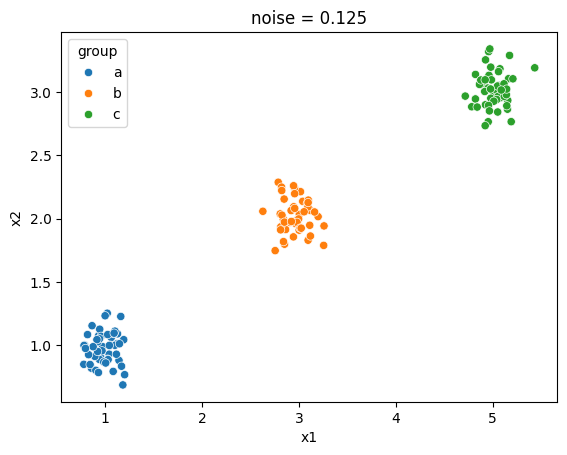

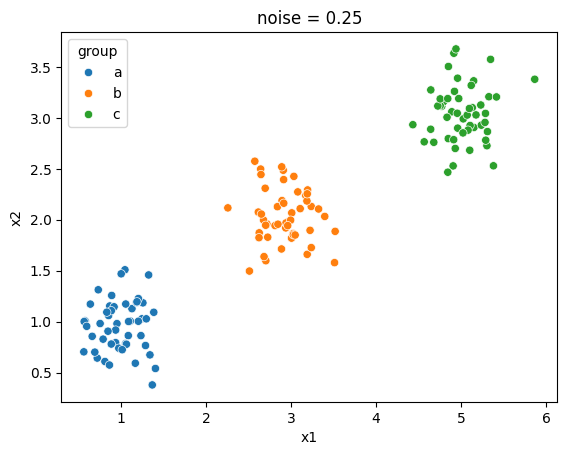

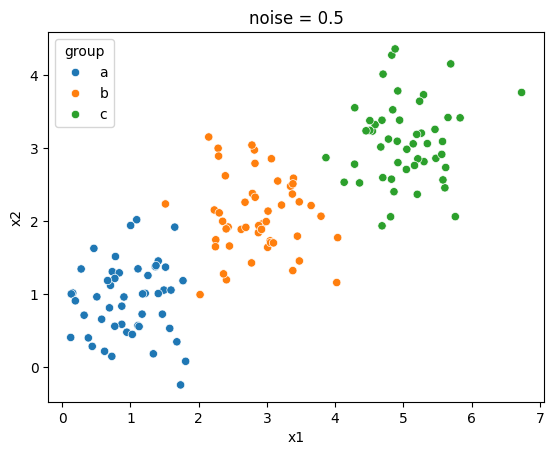

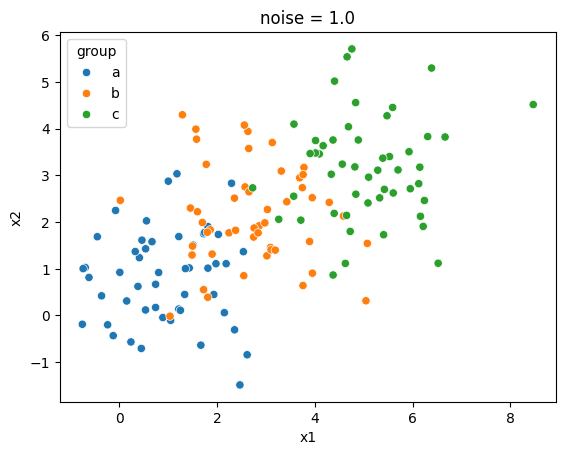

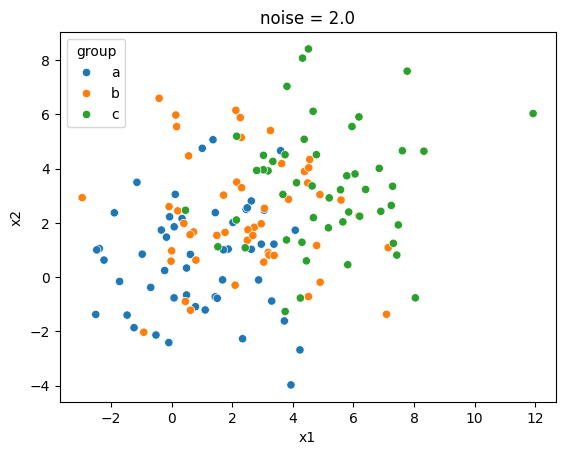

<Figure size 640x480 with 0 Axes>

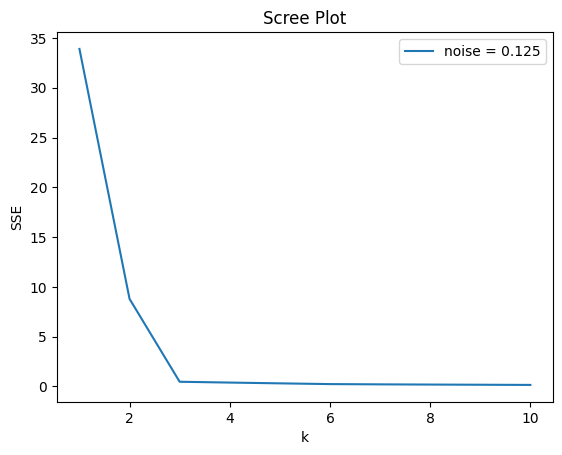

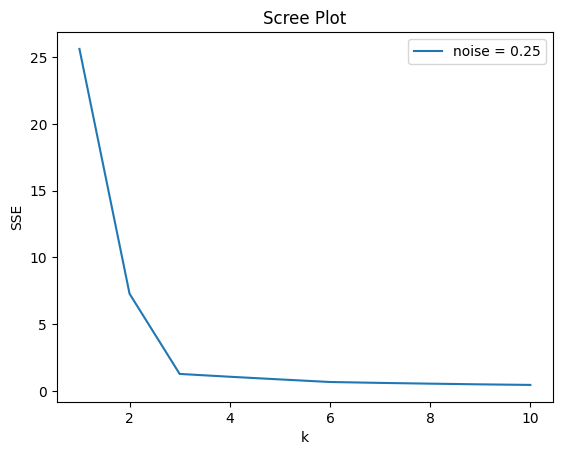

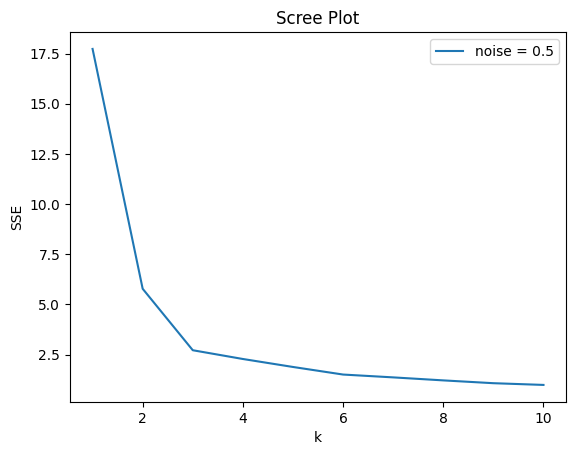

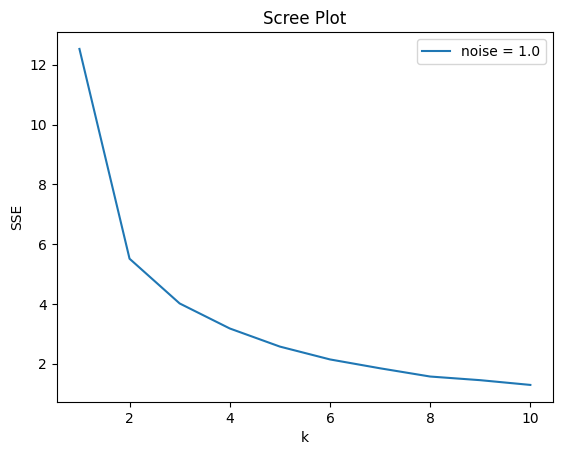

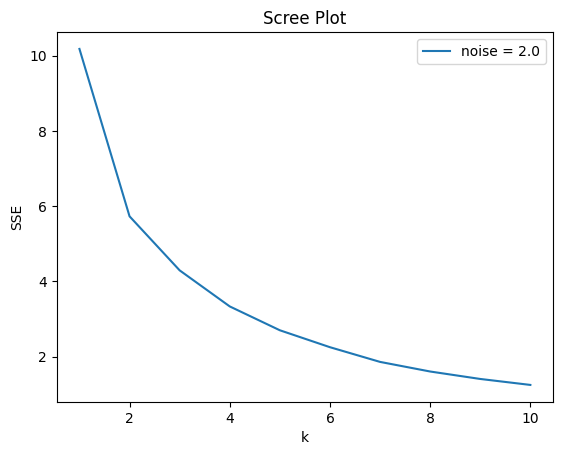

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def createData(noise,N=50):
    np.random.seed(100) # Set the seed for replicability
    # Generate (x1,x2,g) triples:
    X1 = np.array([np.random.normal(1,noise,N),np.random.normal(1,noise,N)])
    X2 = np.array([np.random.normal(3,noise,N),np.random.normal(2,noise,N)])
    X3 = np.array([np.random.normal(5,noise,N),np.random.normal(3,noise,N)])
    # Concatenate into one data frame
    gdf1 = pd.DataFrame({'x1':X1[0,:],'x2':X1[1,:],'group':'a'})
    gdf2 = pd.DataFrame({'x1':X2[0,:],'x2':X2[1,:],'group':'b'})
    gdf3 = pd.DataFrame({'x1':X3[0,:],'x2':X3[1,:],'group':'c'})
    df = pd.concat([gdf1,gdf2,gdf3],axis=0)
    return df

df0_125 = createData(0.125)
df0_25 = createData(0.25)
df0_5 = createData(0.5)
df1_0 = createData(1.0)
df2_0 = createData(2.0)


#2 Scatterplots
datasets = {'0.125': df0_125, '0.25': df0_25, '0.5': df0_5, '1.0': df1_0, '2.0': df2_0}

for noise in datasets:
    plt.figure()
    sns.scatterplot(data=datasets[noise], x='x1', y='x2', hue = 'group').set(title=f"noise = {noise}")

plt.figure()

#as the noise goes up from .125 to 2.0, the visual distinctiveness of the clusters decreases
#At .125 there are clear distinct clusters; at .25 and .5 the clusters are still visible
#at 1.0 and 2.0 there are no obvious visually disctinct clusters.


#3 Scree Plot

from sklearn.cluster import KMeans

ks = np.arange(1, 11)

for noise in datasets:
  df=datasets[noise]
  features = ['x1', 'x2']
  unscaled = df[features]
  mins = unscaled.min()
  maxs = unscaled.max()
  ranges = maxs- mins
  x = (unscaled - mins)/ ranges

  SSE = [
      KMeans(n_clusters=k, max_iter=300, n_init=10, random_state=100)
      .fit(x).inertia_

      for k in ks

  ]

#individual Scree plots
  plt.figure()
  plt.plot(ks, SSE, label=f'noise = {noise}')
  plt.title("Scree Plot")
  plt.xlabel("k")
  plt.ylabel("SSE")
  plt.legend()
  plt.show()

#across plots, it appears that as the noise increases, the elbow at k = 3 begins to disappear
#at low noise (.125 and .25) the eblow at k =3 is very clear and there is no clear elbow at 1.0 and 2.0
#a less clear elbow (less of a drop in SSE) makes selecting the best value of k more difficult
#It also appears that higher noise starts with a lower SSE (at k=1) as seen by the vertical axis\



#4: Intuition of the elbow
#Increasing k generally reduces SSE, so finding the point where an increase of 1 in k causes a larger decrease
#in SSE (aka the elbow) is the best option for k
#As seen by the first set of graphs, there is clearly 3 groups. When k is smaller than the number of groups, KMean
#must cluster 2 groups into one. As a result, the SSE is high. When k=the number of actual groups, the SSE drops signifigantly
#since each group is grouped on their own. Further increases of k clusters would only break up the existing 3 groups
#With more noise, the groups overlap, making separating groups more difficult and changing the k reduces the SSE less,
#since the noise makes it difficult to group correctly.






**Q2.** This question is a case study on clustering.

1. Load the `SIPRI Military Expenditure Database.csv` file in the `./data` folder. This has data about military spending by country. Filter the rows to select only the year 2020, and drop all rows with missing values. I ended up with 148 countries. Is any further cleaning of the variables required?
2. Max-min normalize `Spending (2020 USD)` and `Spending per Capita`. Use a scree plot to determine the optimal number of clusters for the $k$ means clustering algorithm. Make a scatter plot of `Spending (2020 USD)` and `Spending per Capita`, and hue the dots by their cluster membership. Compute a describe table conditional on cluster membership (i.e. `.groupby(cluster).describe()`). What do you see? Where is the United States? Do you notice any patterns in the cluster membership?
3. Repeat part 2 for `Percent of Government Spending` and `Percent of GDP`. How do your results compare to part 2?
4. Use $k$ means clustering with all four numeric variables: `Spending (2020 USD)`, `Spending per Capita`, `Percent of Government Spending`, and `Percent of GDP`. How do your results compare to the previous two parts?
5. Did the $k$-MC algorithm find any useful patterns for you in analyzing the spending?

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import drive
drive.mount ('/content/drive')


df = pd.read_csv('/content/drive/MyDrive/SIPRI Military Expenditure Database.csv')

#1 cleaning
#filter by year (2020)
df = df.loc[df['Year'] == 2020].dropna()

print(df.shape)
print(df.dtypes)
print(df.describe())

#no further cleaning is necessary:
#the 4 money/ percent variables are already floats; country is okay as an object; year is irrelavant (only 2020)
#shape matches the 148 in the question


#2 minmax normalize


#scree plot
from sklearn.cluster import KMeans
features = ["Spending (2020 USD)", "Spending per Capita"]
unscaled = df[features]
mins = unscaled.min()
maxs = unscaled.max()
ranges = maxs- mins
x = (unscaled - mins)/ ranges

ks = np.arange(1,11)

SSE = [
      KMeans(n_clusters=k, max_iter=300, n_init=10, random_state=100)
      .fit(x).inertia_

      for k in ks
  ]
sns.lineplot(x=ks, y=SSE).set(title="Scree Plot", xlabel = "k", ylabel="SSE")
plt.figure()

#elbow at k =4

#scatterplot
model = KMeans(n_clusters=4, max_iter=300, n_init=10, random_state=100).fit(x)
df["cluster"] = model.labels_
sns.scatterplot(data=df, x = "Spending (2020 USD)", y = "Spending per Capita", hue = 'cluster')

#describe table
print(df[features + ["cluster"]].groupby("cluster").describe())

plt.figure()

for country in sorted(df["cluster"].unique()):
  print(country, df.loc[df["cluster"] == country, "Country"].tolist())

#there is a clear elbow (drop off in SSE)at k = 4
#the 4 clusters are mostly separated based on spending per capita, as seen in the scatterplot (no clear grouping across x except for US)
#the US is alone in cluster 2 (why the SD is NaN) and is by far the highest spender overall
# cluster 3 has 6 countries and the highest spending per capita
# cluster 0 has 111 countries and cluster 1 has 30 countries; both spend less per capita than the other two groups
#4/6 of cluster 3's countries are in the middle east




#3 Repeat 2 with Percent of Government Spending and Percent of GDP

#scree
features = ["Percent of Government Spending", "Percent of GDP"]
unscaled = df[features]
mins = unscaled.min()
maxs = unscaled.max()
ranges = maxs- mins
x = (unscaled - mins)/ ranges

ks = np.arange(1,11)

SSE = [
      KMeans(n_clusters=k, max_iter=300, n_init=10, random_state=100)
      .fit(x).inertia_

      for k in ks
  ]
sns.lineplot(x=ks, y=SSE).set(title="Scree Plot", xlabel = "k", ylabel="SSE")
plt.figure()

#elbow at k = 3 (very faint)

#scatterplot
model = KMeans(n_clusters=3, max_iter=300, n_init=10, random_state=100).fit(x)
df["cluster"] = model.labels_
sns.scatterplot(data=df, x = "Percent of Government Spending", y = "Percent of GDP", hue = 'cluster')

#describe table
print(df[features + ["cluster"]].groupby("cluster").describe())

plt.figure()


for country in sorted(df["cluster"].unique()):
  print(country, df.loc[df["cluster"] == country, "Country"].tolist())

#the elbow is much less sharp than in part 2
#US no longer in its own cluster (now in cluster 0); each cluster has multiple countries
#the clusters for part 2 were largely driven by the y; here is seems more even (x and y influence)
#It makes sense that more war torn countries (Isreal, Pakistan) are in the highest cluster

#4: KMeans clustering with 4 numeric variables

#scree
features = ["Spending (2020 USD)", "Spending per Capita", "Percent of Government Spending", "Percent of GDP"]
unscaled = df[features]
mins = unscaled.min()
maxs = unscaled.max()
ranges = maxs- mins
x = (unscaled - mins)/ ranges

ks = np.arange(1,11)

SSE = [
      KMeans(n_clusters= k, max_iter=300, n_init=10, random_state=100)
      .fit(x).inertia_

      for k in ks
  ]
sns.lineplot(x=ks, y=SSE).set(title="Scree Plot", xlabel = "k", ylabel="SSE")
plt.figure()

#no clear elbow: SSE keeps dropping by similar amounts; set k = 4

model = KMeans(n_clusters=4, max_iter=300, n_init=10, random_state=100).fit(x)
df["cluster"] = model.labels_

#describe table
print(df[features + ["cluster"]].groupby("cluster").describe())


for country in sorted(df["cluster"].unique()):
  print(country, df.loc[df["cluster"] == country, "Country"].tolist())

#the clusters combine both wealth/ spending per capital and the millitary spending of the country
#Unlike part 2, the US is not in its own group
#the 4 variables makes it difficult to see a true elbow, therefore selecting k is essentially arbitrary
#it appears the 4 groups are roughly: wealthy countries  + a lot of military spending, wealthy countries with little military spending,
#poor countries with a lot of military spending, poor countries with no military spending; this is a great simplification


#5
#KMeans showed to be useful for groupings like poor vs rich in part 2 and high vs low military burden in part 3, but once you start introducing
#more than 2 variables (like in part 4), this approach becomes less useful, as the clustering becomes more difficult
#additionally, the clustering depends greatly on what variables are used
#additionally, throughout this anaylsis, it appears that most countries get grouped into a large lower cluster












## *Phase 1: Solution without AI

Complete all questions in the following cells without generative AI. Then commit and push the
notebook before beginning Phase 2.

**Declaration:** I completed this version without generative AI.

**Student(s):** [To be provided]

**Date:** [To be provided]

In [ ]:
# Your Phase 1 solution to the problem goes here.


## *Phase 2: AI-assisted Revision
Keep Phase 1 frozen.

- **Phase 1 commit SHA ID:** [To be provided]
- **AI tool and model used:** [To be provided]

### *Prompts used

1. [Paste prompt]
2. [Paste follow-up prompt]

### *AI-proposed changes


[Paste the AI's concise numbered list verbatim.]

1. ...
2. ...

### *Evaluation of AI suggestions


| Change | Decision | Reason and verification |
|---|---|---|
| 1 | Accept / modify / reject | ... |
| 2 | Accept / modify / reject | ... |

### *AI-assisted solution in full
After the evaluation of AI suggestions, incorporate the accepted revisions into your Phase 1 solution and provide the final Phase 2 solution in full in the following cells.

In [ ]:
# Your Phase 2 solution to the problem goes here.


### *Reflection on AI assistance
In your own words without generative AI.

[In 150–300 words, describe the main improvements, AI mistakes or limitations, how the final solution was verified, and any remaining concerns.]